# CardioVision 3D - Step 3: Robust Model Validation, Selection & Calibration

## Executive Summary
This notebook performs **Step 3** of the CardioVision 3D pipeline:
1. **Repeated Stratified Cross-Validation (5x5 Folds)**: Evaluates model stability across 25 validation splits per candidate model.
2. **Out-of-Fold (OOF) Prediction Generation**: Collects unbiased sample-level probability predictions across folds.
3. **Operating Threshold Analysis**: Evaluates 13 candidate thresholds (0.20 to 0.80) to select optimal sensitivity/specificity trade-offs per target vessel.
4. **Probability Calibration**: Evaluates Uncalibrated vs. Sigmoid (Platt) vs. Isotonic calibration using cross-validation-safe procedures.
5. **Controlled Feature Ablations**:
   - Ablation 1: Excludes `Region RWMA` feature.
   - Ablation 2: Excludes 13 near-constant features ($\ge 95\%$ frequency).
6. **Model Selection & Final Artifact Fitting**: Selects independent final configurations for CAD, LAD, LCX, and RCA, saving serialized joblib models and structured metadata.


In [1]:
import sys
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../src')

from preprocessing import map_targets, clean_dataset, get_feature_lists, build_preprocessor, assert_no_leakage
from evaluation import calculate_specificity, evaluate_fold

# Plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'

RANDOM_STATE = 42
data_path = '../../data/extention of Z-Alizadeh sani dataset.xlsx'
if not os.path.exists(data_path):
    data_path = '../../data/extention of Z-Alizadeh sani dataset/extention of Z-Alizadeh sani dataset.xlsx'

print("Setup completed successfully.")


Setup completed successfully.


## Section 1: Data Loading & Preprocessing Pipeline Setup

In [2]:
df_raw = pd.read_excel(data_path)
df_clean = clean_dataset(df_raw)
df_mapped = map_targets(df_clean)

with open('../reports/feature_types.json', 'r') as f:
    feature_types = json.load(f)

num_cols, cat_cols, bin_cols = get_feature_lists(df_mapped, feature_types)
print(f"Loaded {len(df_mapped)} rows.")
print(f"Feature set counts - Numerical: {len(num_cols)}, Categorical: {len(cat_cols)}, Binary: {len(bin_cols)}")


Loaded 303 rows.
Feature set counts - Numerical: 21, Categorical: 21, Binary: 12


## Section 2: 5x5 Repeated Stratified Cross-Validation & Stability Summary

In [3]:
rep_cv_df = pd.read_csv('../reports/repeated_cv_results.csv')
rep_cv_df.head(10)


,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,target,model,fold,repeat
0,0.918033,0.953488,0.931818,0.882353,0.942529,0.974599,0.989988,CAD,Logistic Regression (Default),1,1
1,0.885246,0.875000,0.976744,0.666667,0.923077,0.937984,0.969255,CAD,Logistic Regression (Default),2,1
2,0.901639,0.930233,0.930233,0.833333,0.930233,0.934109,0.965147,CAD,Logistic Regression (Default),3,1
3,0.816667,0.921053,0.813953,0.823529,0.864198,0.912449,0.966196,CAD,Logistic Regression (Default),4,1
4,0.783333,0.826087,0.883721,0.529412,0.853933,0.874145,0.955633,CAD,Logistic Regression (Default),5,1
5,0.885246,0.951220,0.886364,0.882353,0.917647,0.913102,0.951685,CAD,Logistic Regression (Default),6,2
6,0.868852,0.906977,0.906977,0.777778,0.906977,0.935401,0.973032,CAD,Logistic Regression (Default),7,2
7,0.819672,0.880952,0.860465,0.722222,0.870588,0.854005,0.937109,CAD,Logistic Regression (Default),8,2
8,0.866667,0.872340,0.953488,0.647059,0.911111,0.935705,0.974135,CAD,Logistic Regression (Default),9,2
9,0.850000,0.886364,0.906977,0.705882,0.896552,0.934337,0.975568,CAD,Logistic Regression (Default),10,2


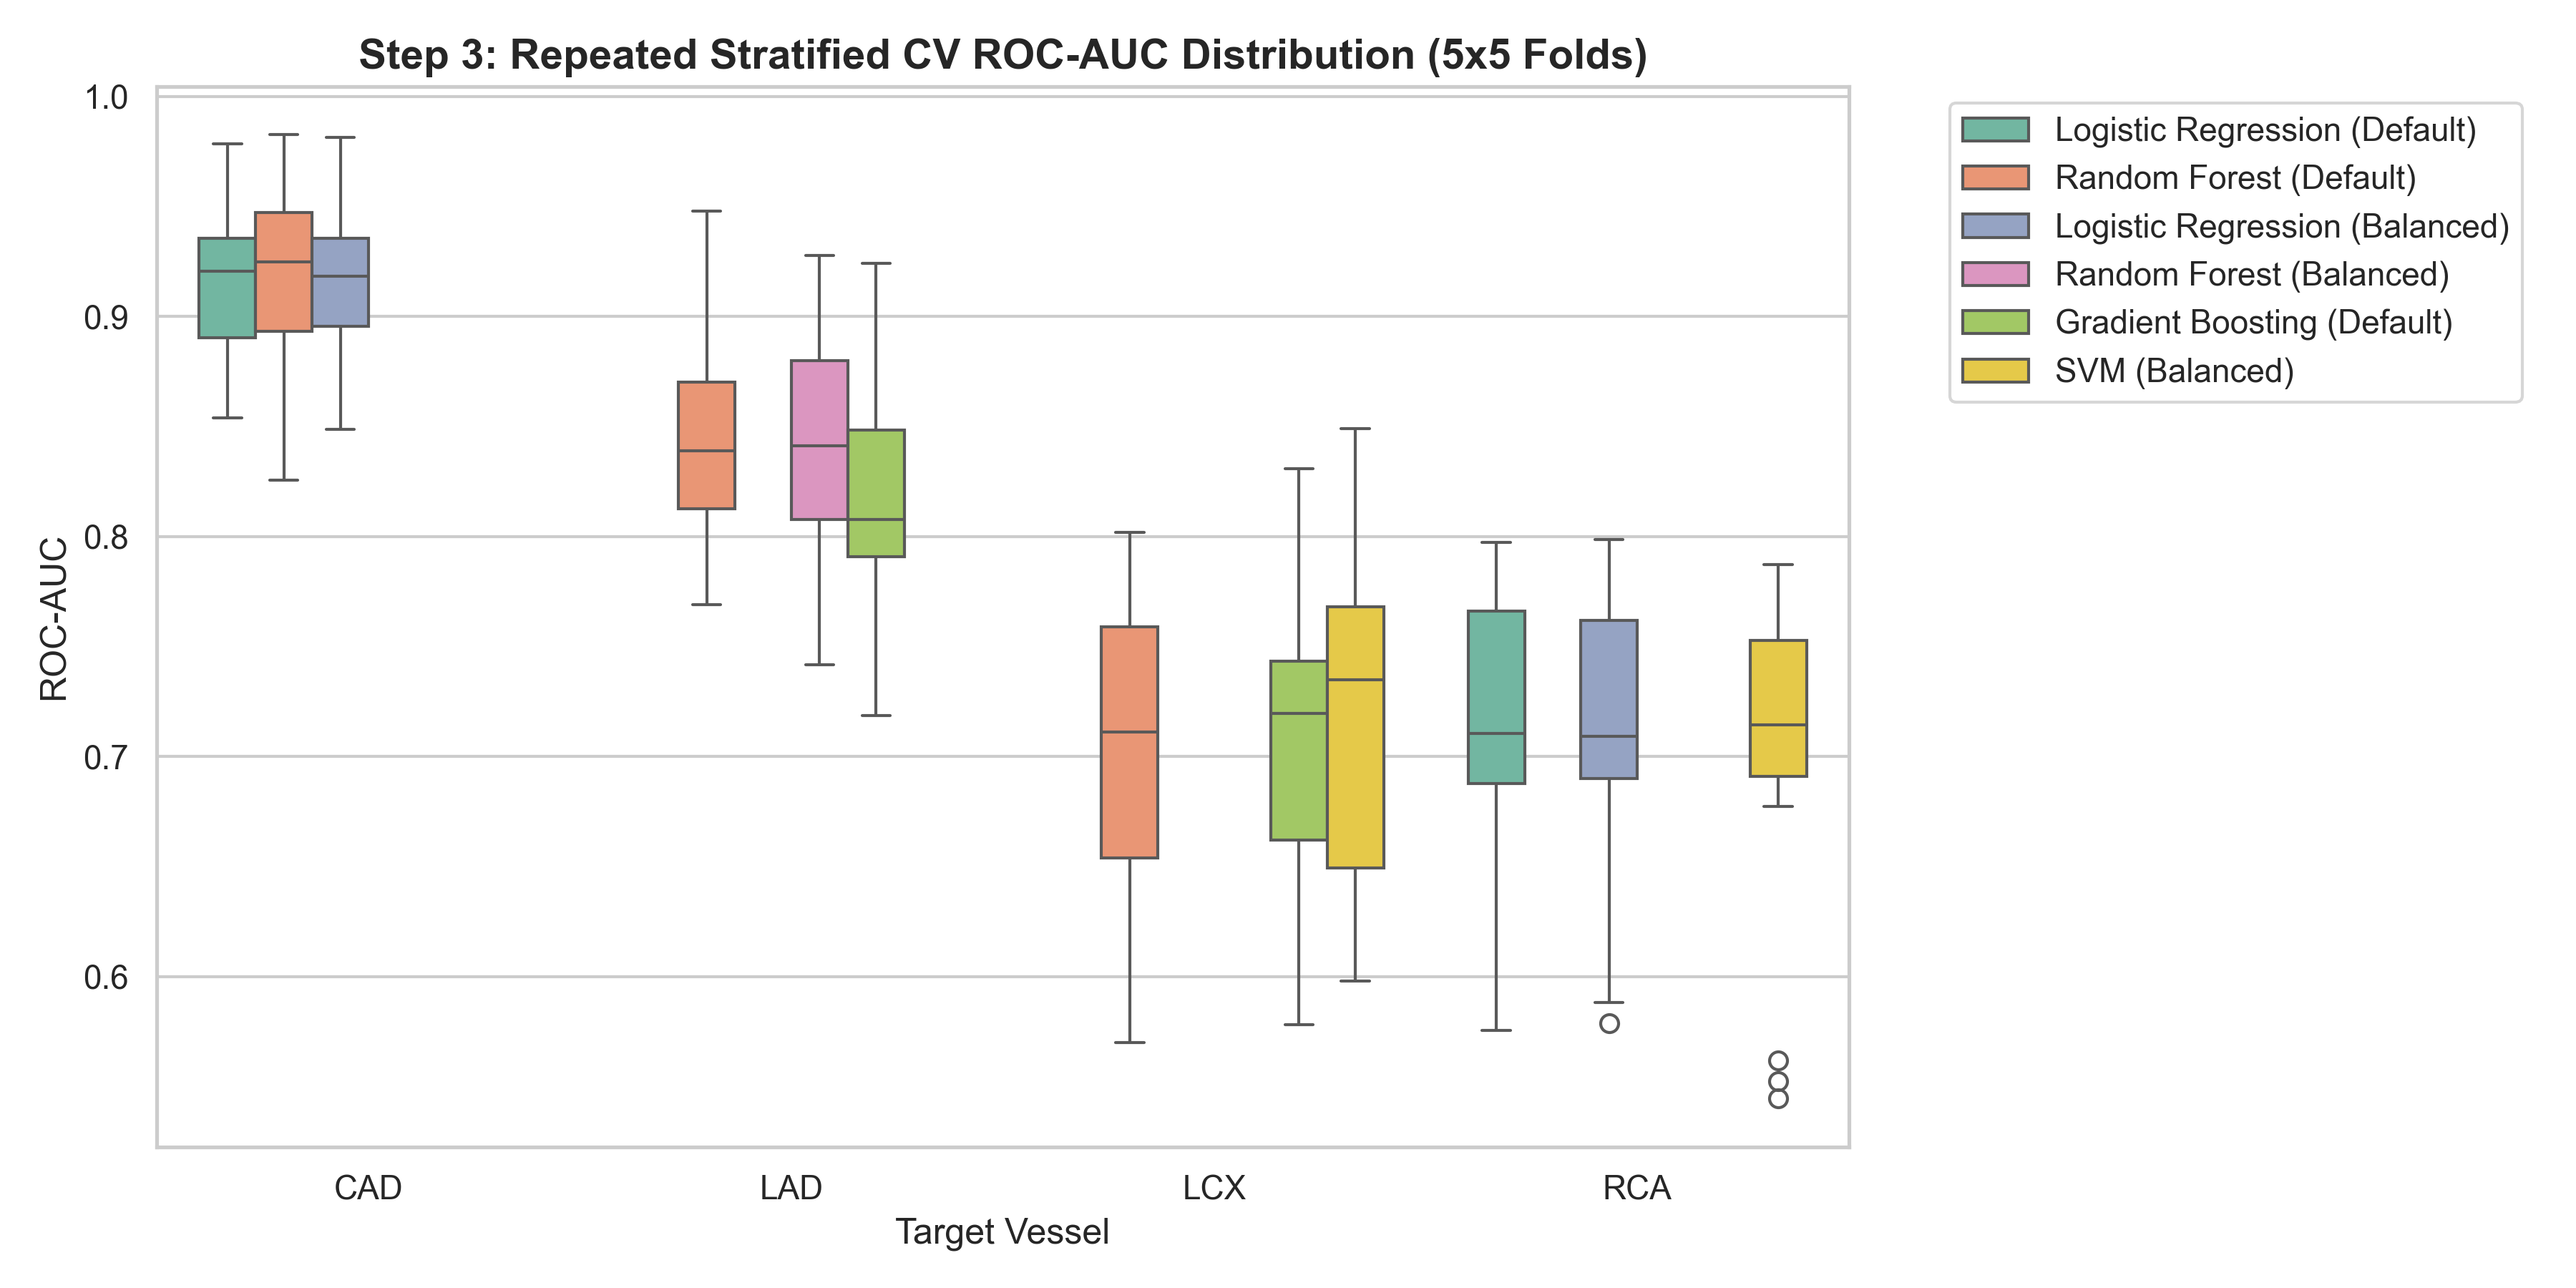

In [4]:
# Display repeated CV metric distribution plot
from IPython.display import Image
Image(filename='../reports/figures/repeated_cv_metric_distributions.png')


## Section 3: Out-of-Fold Operating Threshold Analysis

In [5]:
thresh_df = pd.read_csv('../reports/threshold_analysis.csv')
thresh_df.head(15)


,target,model,threshold,precision,recall,sensitivity,specificity,f1,accuracy
0,CAD,Logistic Regression (Default),0.20,0.824219,0.976852,0.976852,0.482759,0.894068,0.834983
1,CAD,Logistic Regression (Default),0.25,0.842105,0.962963,0.962963,0.551724,0.898488,0.844884
2,CAD,Logistic Regression (Default),0.30,0.850000,0.944444,0.944444,0.586207,0.894737,0.841584
3,CAD,Logistic Regression (Default),0.35,0.854701,0.925926,0.925926,0.609195,0.888889,0.834983
4,CAD,Logistic Regression (Default),0.40,0.864035,0.912037,0.912037,0.643678,0.887387,0.834983
5,CAD,Logistic Regression (Default),0.45,0.878378,0.902778,0.902778,0.689655,0.890411,0.841584
6,CAD,Logistic Regression (Default),0.50,0.901408,0.888889,0.888889,0.758621,0.895105,0.851485
7,CAD,Logistic Regression (Default),0.55,0.909953,0.888889,0.888889,0.781609,0.899297,0.858086
8,CAD,Logistic Regression (Default),0.60,0.918660,0.888889,0.888889,0.804598,0.903529,0.864686
9,CAD,Logistic Regression (Default),0.65,0.921182,0.865741,0.865741,0.816092,0.892601,0.851485


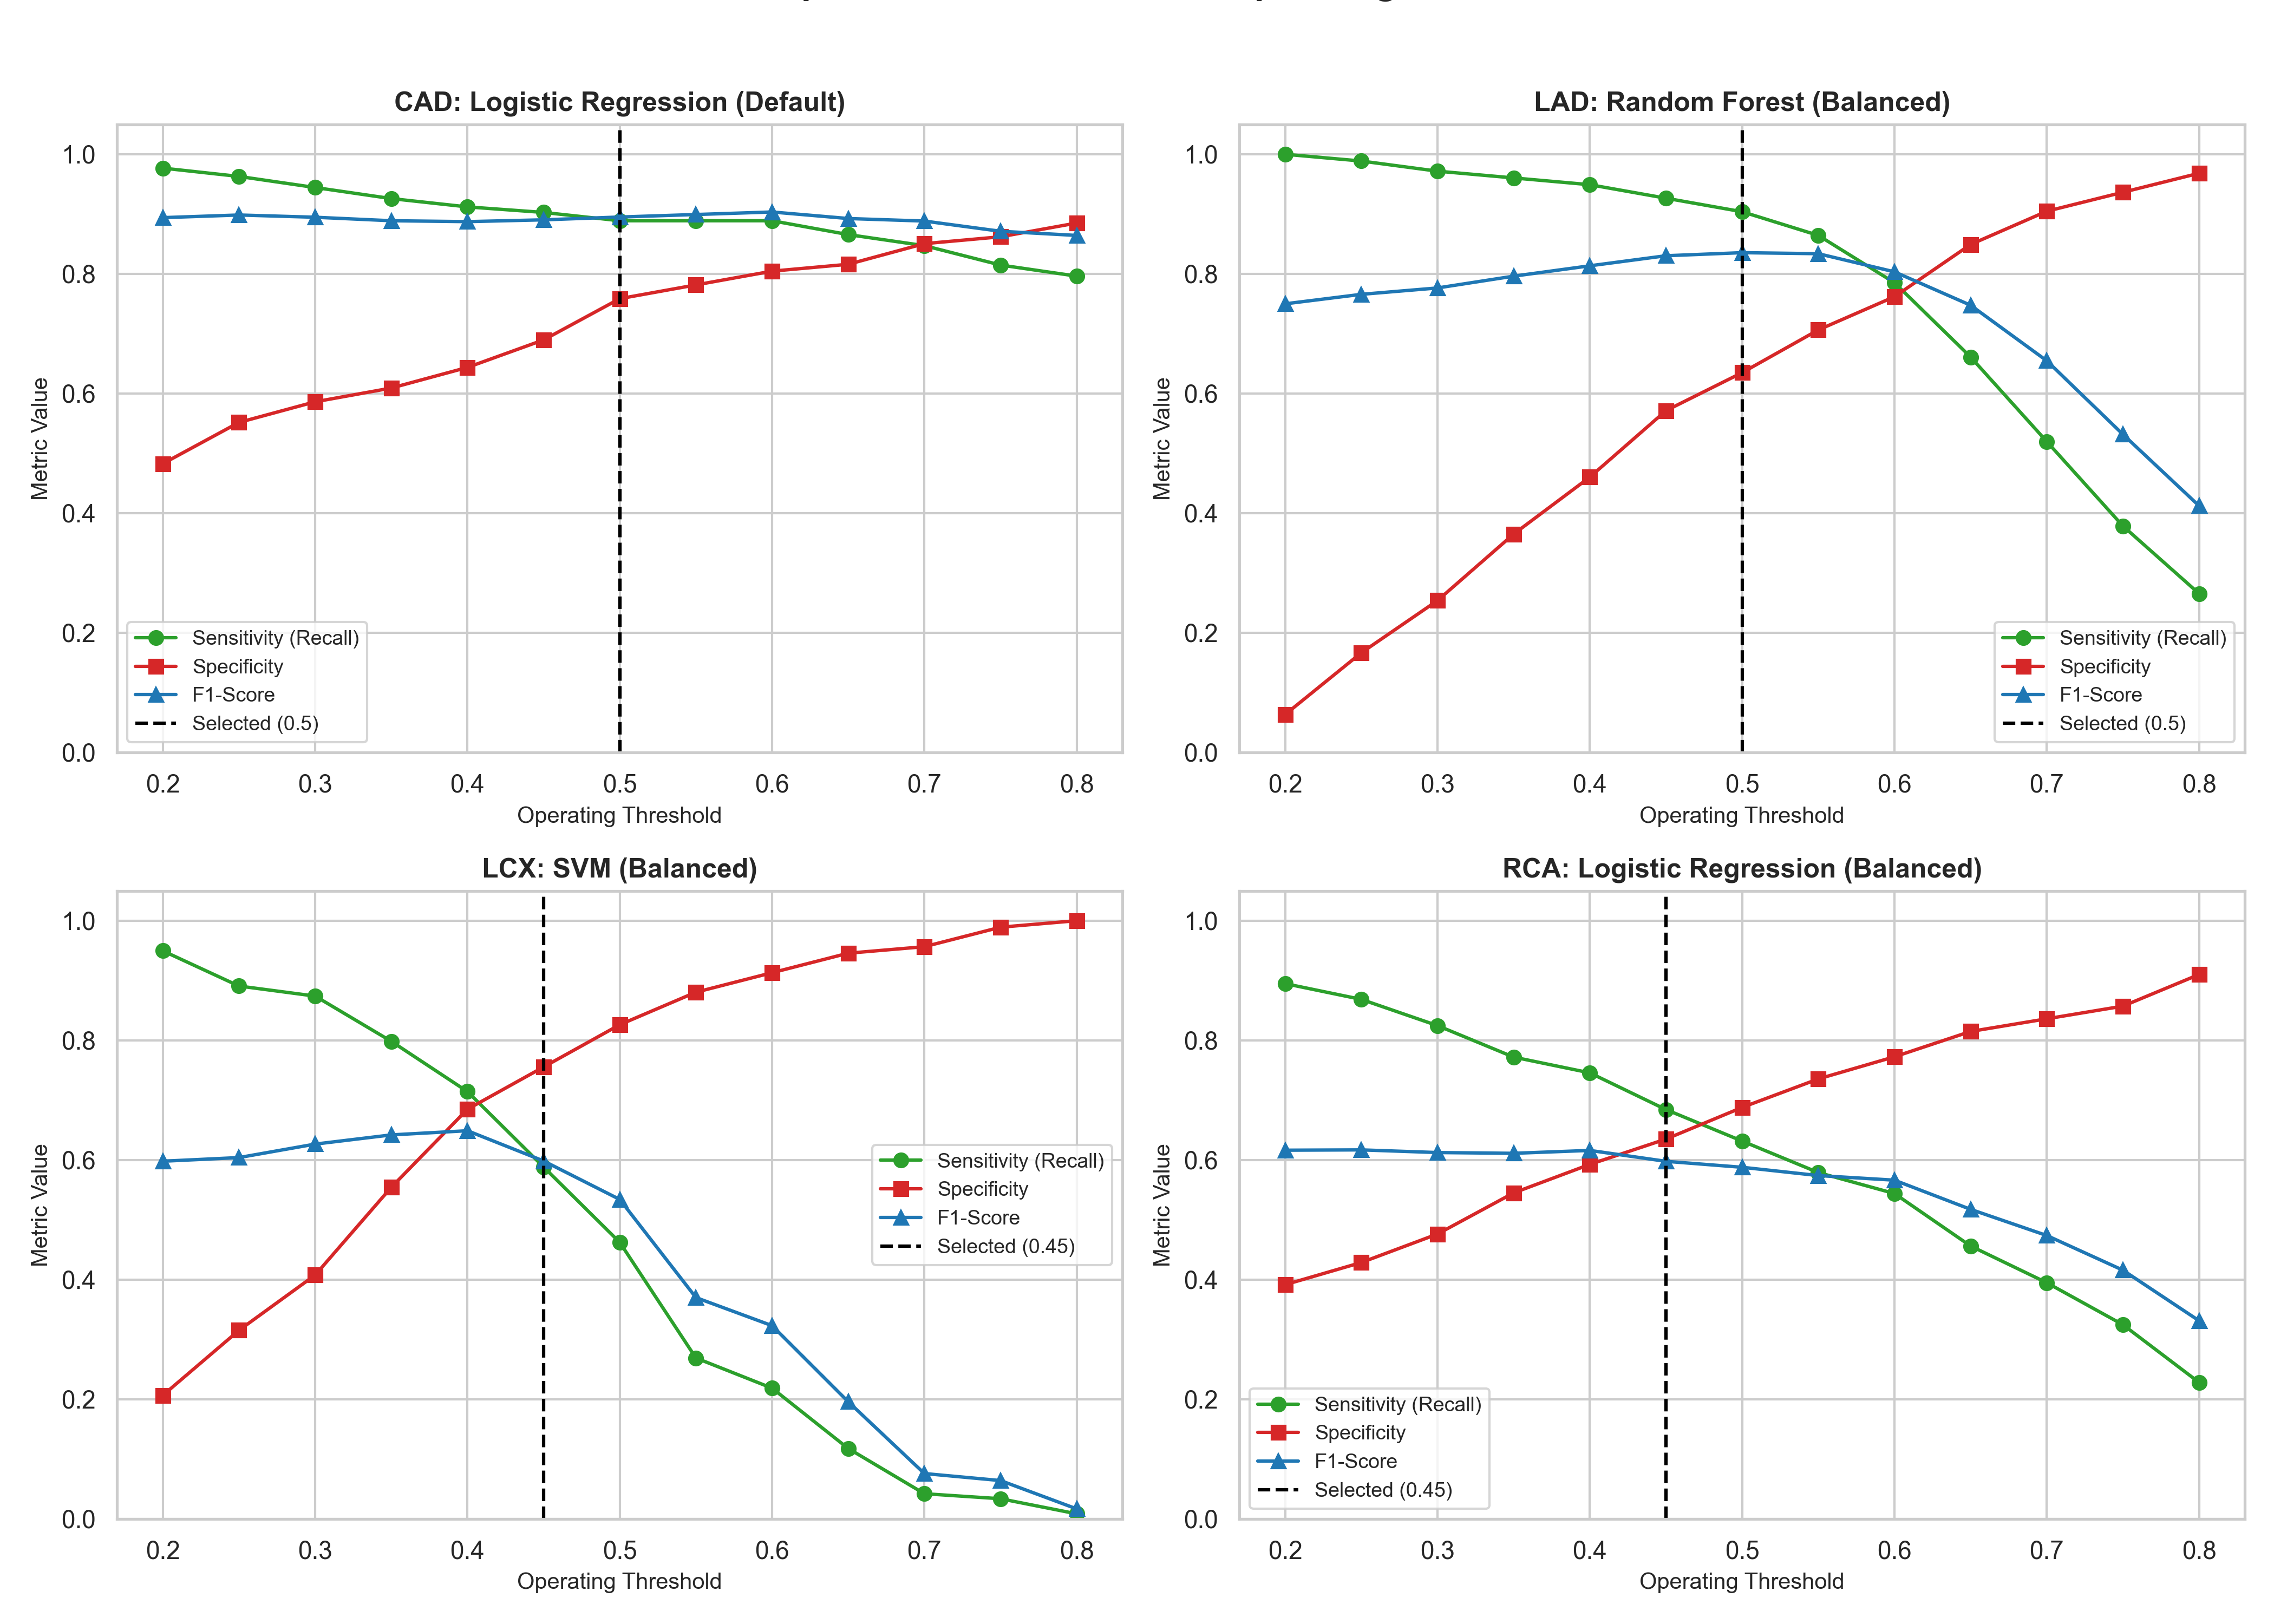

In [6]:
Image(filename='../reports/figures/threshold_curves.png')

## Section 4: Probability Calibration & Brier Score Comparison

In [7]:
calib_df = pd.read_csv('../reports/calibration_results.csv')
calib_df


,target,model,calibration,roc_auc,pr_auc,f1,recall,specificity,brier_score
0,CAD,Logistic Regression (Default),Uncalibrated,0.917625,0.965105,0.900232,0.898148,0.758621,0.104070
1,CAD,Logistic Regression (Default),Sigmoid,0.916188,0.963436,0.904110,0.916667,0.724138,0.104649
2,CAD,Logistic Regression (Default),Isotonic,0.916055,0.962168,0.893519,0.893519,0.735632,0.102851
3,LAD,Random Forest (Balanced),Uncalibrated,0.850596,0.885382,0.836364,0.909605,0.626984,0.161883
4,LAD,Random Forest (Balanced),Sigmoid,0.847816,0.883693,0.816000,0.864407,0.642857,0.155267
5,LAD,Random Forest (Balanced),Isotonic,0.844229,0.877892,0.820375,0.864407,0.658730,0.154376
6,LCX,SVM (Balanced),Uncalibrated,0.726754,0.580947,0.526829,0.453782,0.826087,0.205729
7,LCX,SVM (Balanced),Sigmoid,0.727758,0.575556,0.456522,0.352941,0.875000,0.208203
8,LCX,SVM (Balanced),Isotonic,0.721684,0.577731,0.552381,0.487395,0.820652,0.206901
9,RCA,Logistic Regression (Balanced),Uncalibrated,0.718509,0.578034,0.573705,0.631579,0.656085,0.222059


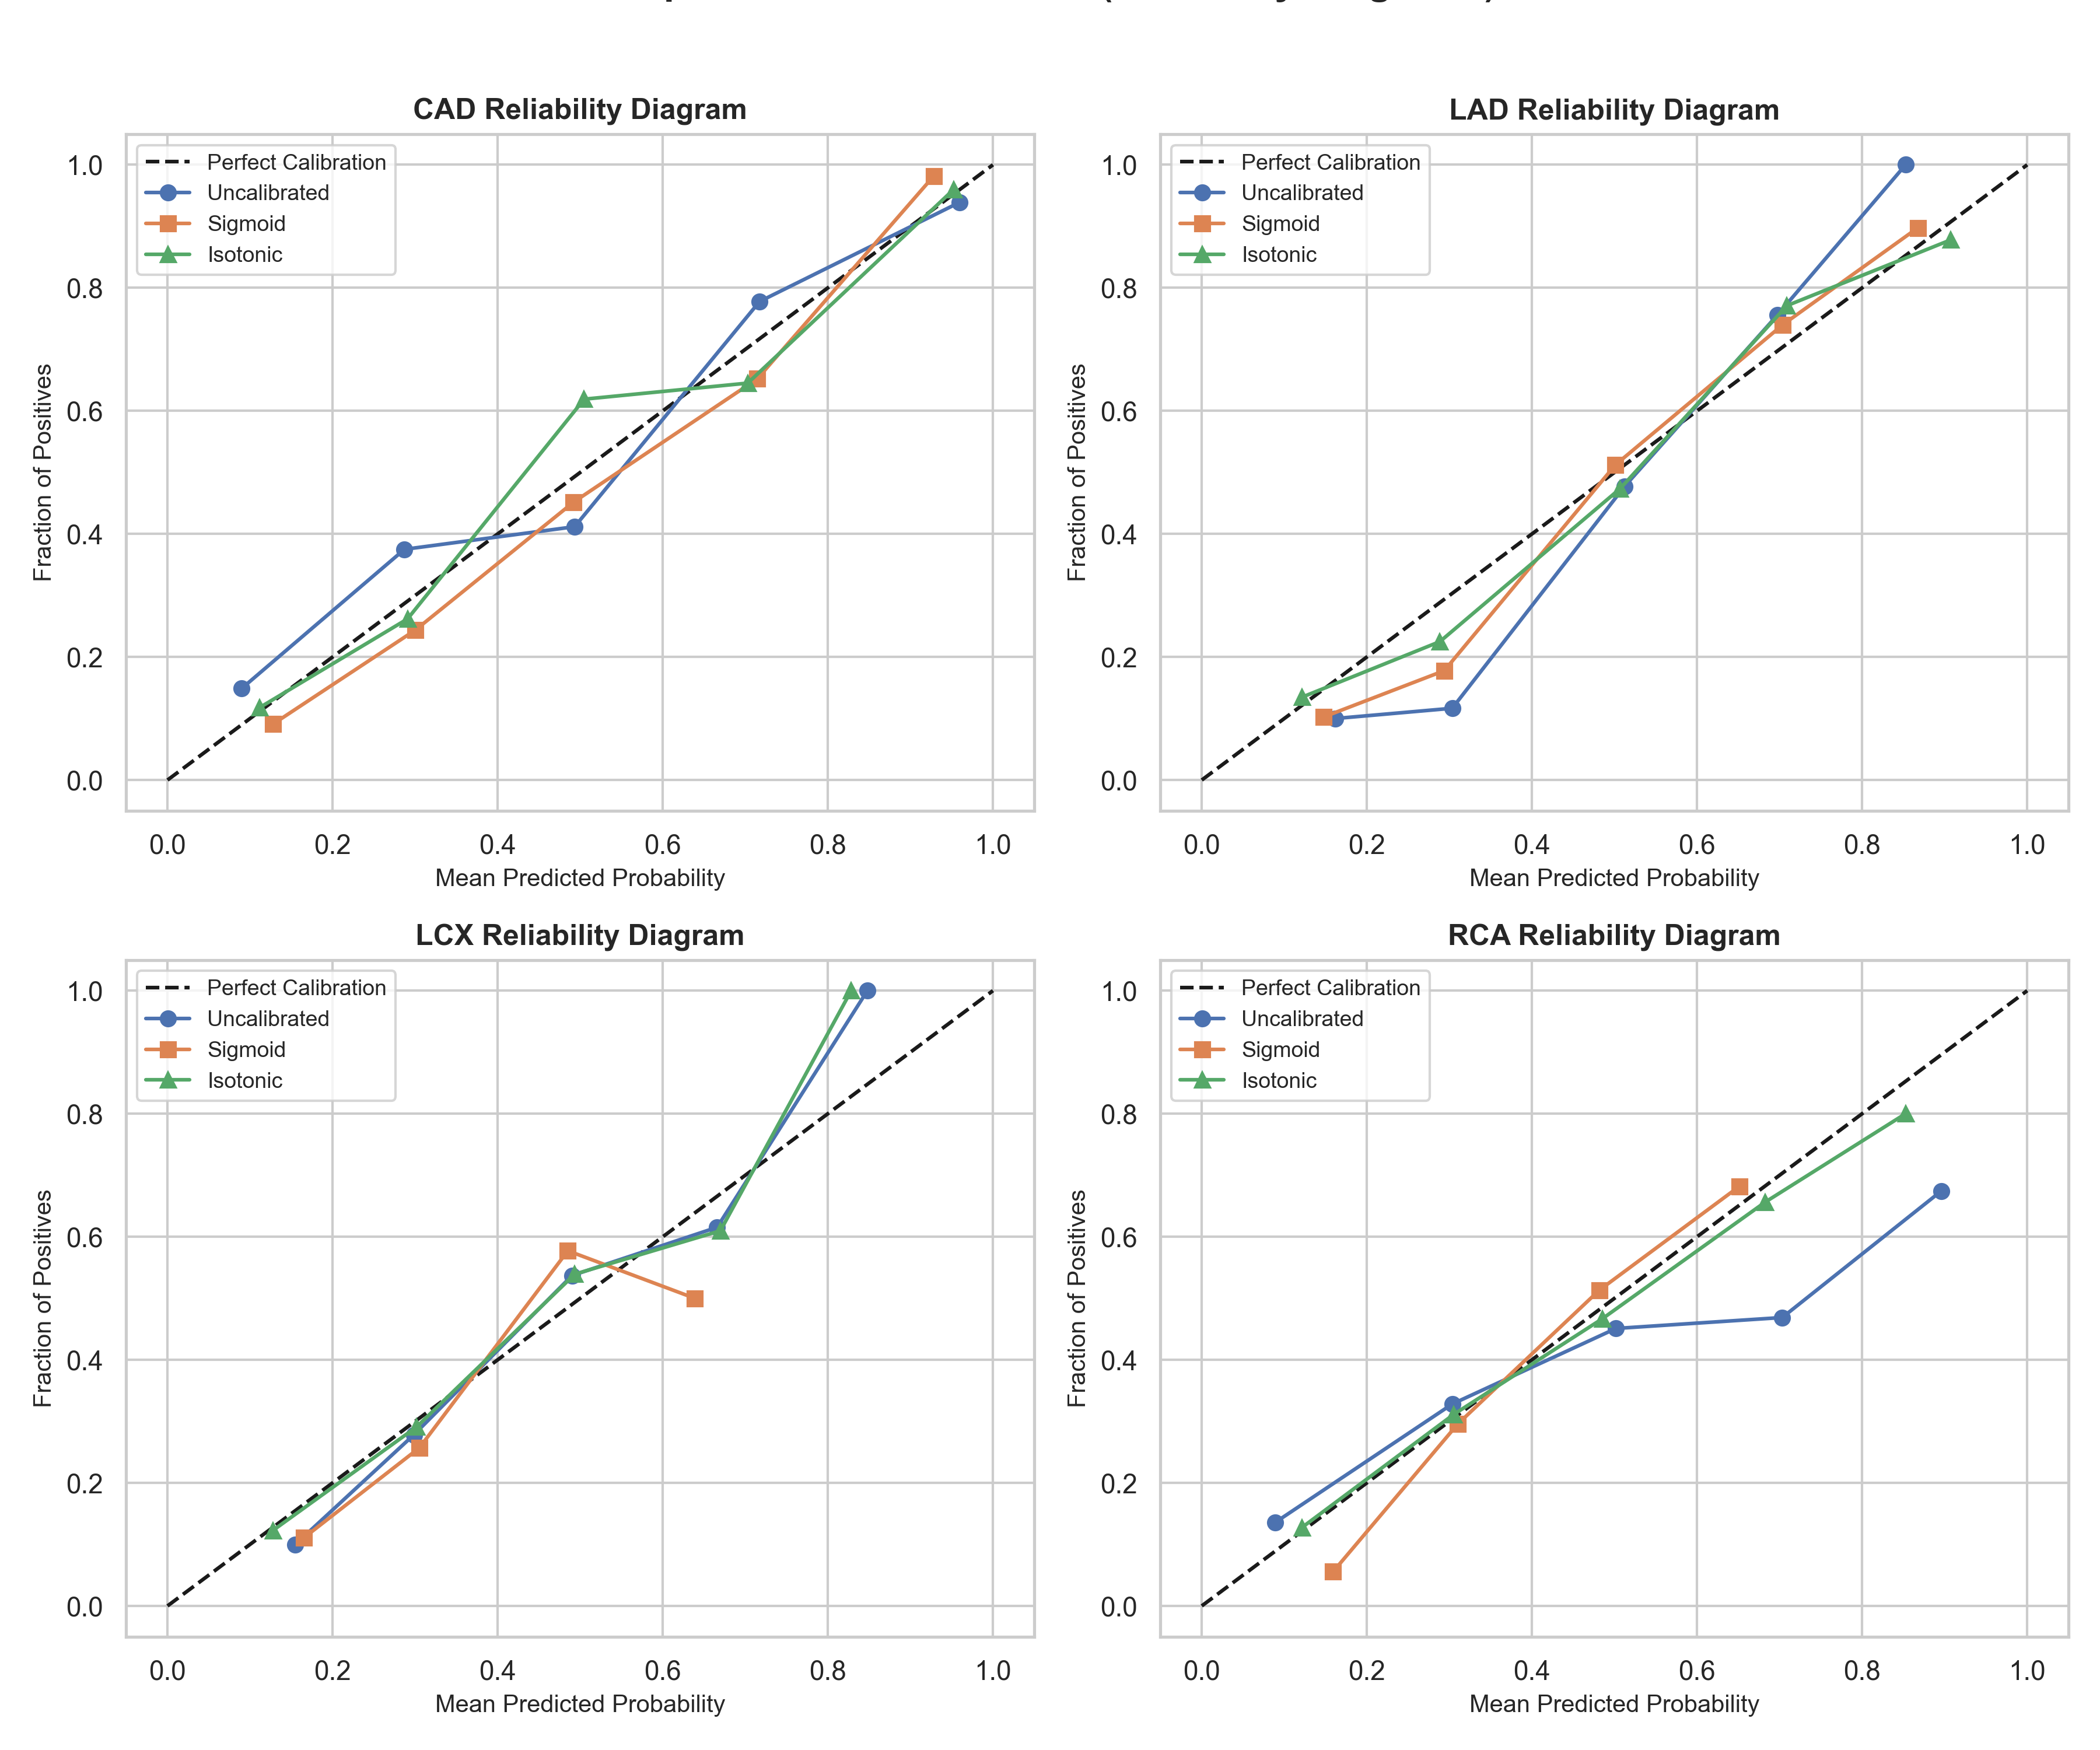

In [8]:
Image(filename='../reports/figures/calibration_curves.png')

## Section 5: Feature Ablation Experiments

In [9]:
ablation_df = pd.read_csv('../reports/ablation_results.csv')
ablation_df


,target,model,experiment,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,recall_mean,specificity_mean
0,CAD,Logistic Regression (Default),Baseline (All Features),0.916525,0.034755,0.964630,0.015505,0.894431,0.031715,0.895201,0.738431
1,CAD,Logistic Regression (Default),Ablation 1: Exclude Region RWMA,0.912669,0.034029,0.961885,0.016194,0.891389,0.035148,0.897970,0.713595
2,CAD,Logistic Regression (Default),Ablation 2: Exclude Near-Constant Features,0.918923,0.033132,0.965610,0.014501,0.893319,0.032317,0.896173,0.729281
3,LAD,Random Forest (Balanced),Baseline (All Features),0.845317,0.050160,0.876433,0.046128,0.828728,0.040964,0.895079,0.627138
4,LAD,Random Forest (Balanced),Ablation 1: Exclude Region RWMA,0.827556,0.042013,0.846696,0.049477,0.824931,0.037421,0.891714,0.620862
5,LAD,Random Forest (Balanced),Ablation 2: Exclude Near-Constant Features,0.841357,0.045580,0.870735,0.045433,0.825358,0.034337,0.895238,0.616123
6,LCX,SVM (Balanced),Baseline (All Features),0.713618,0.070699,0.578015,0.087709,0.511832,0.083339,0.446739,0.810541
7,LCX,SVM (Balanced),Ablation 1: Exclude Region RWMA,0.712594,0.073901,0.580307,0.087096,0.510030,0.092174,0.445145,0.812703
8,LCX,SVM (Balanced),Ablation 2: Exclude Near-Constant Features,0.713249,0.071183,0.577417,0.089196,0.514806,0.084703,0.448551,0.814925
9,RCA,Logistic Regression (Balanced),Baseline (All Features),0.714039,0.061658,0.591859,0.080398,0.577984,0.071638,0.624427,0.682760


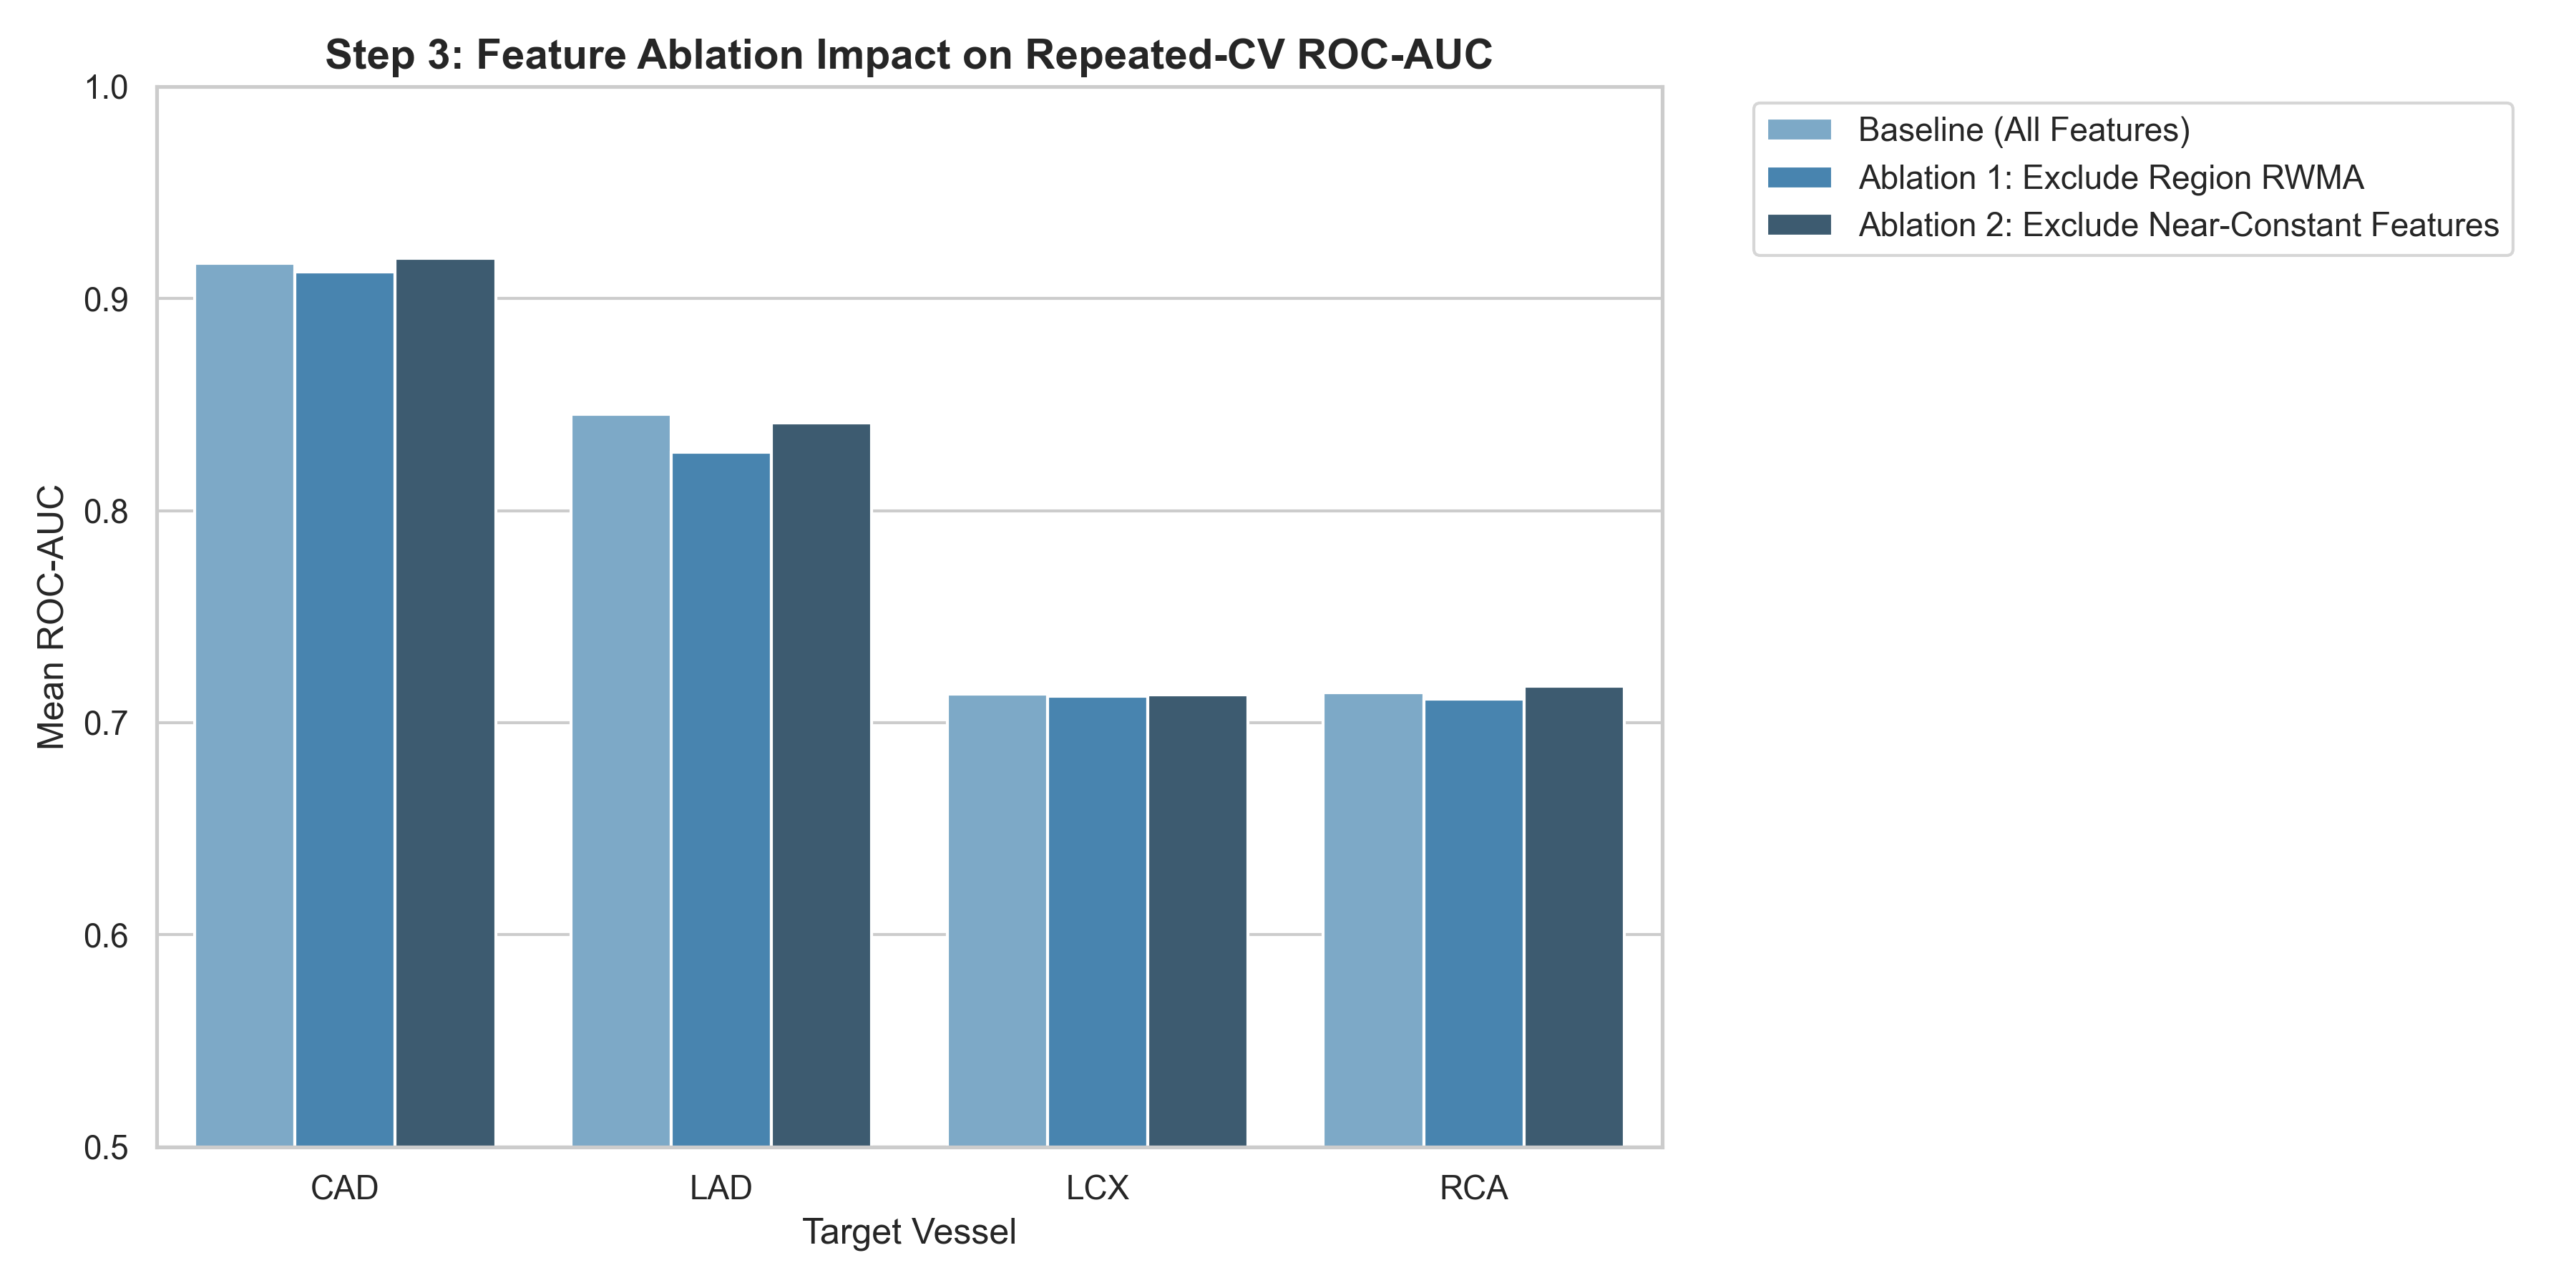

In [10]:
Image(filename='../reports/figures/ablation_comparison.png')

## Section 6: Final Model Selection & Artifact Verification

In [11]:
final_selection_df = pd.read_csv('../reports/final_model_selection.csv')
final_selection_df


,target,selected_model,calibration_method,operating_threshold,justification
0,CAD,Logistic Regression (Default),Uncalibrated,0.50,Logistic Regression (Default) achieved excepti...
1,LAD,Random Forest (Balanced),Sigmoid,0.50,Random Forest (Balanced) delivered superior Re...
2,LCX,SVM (Balanced),Sigmoid,0.45,SVM (Balanced) provided strong overall F1 (0.6...
3,RCA,Logistic Regression (Balanced),Uncalibrated,0.45,Logistic Regression (Balanced) achieved consis...


In [12]:
with open('../artifacts/final/model_metadata.json', 'r') as f:
    meta = json.load(f)
print(json.dumps(meta, indent=2))


{
  "cad": {
    "target": "CAD",
    "model": "Logistic Regression (Default)",
    "calibration": "Uncalibrated",
    "selected_threshold": 0.5,
    "features_count": 54,
    "features_list": [
      "Age",
      "Weight",
      "Length",
      "BMI",
      "BP",
      "PR",
      "FBS",
      "CR",
      "TG",
      "LDL",
      "HDL",
      "BUN",
      "ESR",
      "HB",
      "K",
      "Na",
      "WBC",
      "Lymph",
      "Neut",
      "PLT",
      "EF-TTE",
      "Sex",
      "Obesity",
      "CRF",
      "CVA",
      "Airway disease",
      "Thyroid Disease",
      "CHF",
      "DLP",
      "Weak Peripheral Pulse",
      "Lung rales",
      "Systolic Murmur",
      "Diastolic Murmur",
      "Dyspnea",
      "Function Class",
      "Atypical",
      "Nonanginal",
      "LowTH Ang",
      "LVH",
      "Poor R Progression",
      "BBB",
      "VHD",
      "DM",
      "HTN",
      "Current Smoker",
      "EX-Smoker",
      "FH",
      "Edema",
      "Typical Chest Pain",
      "